# Phase 5 — AI/LLM Layer: Executive Summaries & RAG Chatbot

**SaaSGuard Phase 5** adds a natural-language AI layer on top of the Phase 4 churn prediction pipeline.

| Section | Content |
|---|---|
| 5.1 | Prompt engineering — raw prompts + Groq API responses |
| 5.2 | Guardrail test cases — passing and failing examples with flags |
| 5.3 | Sample summaries by audience (CSM vs executive) for 3 customer profiles |
| 5.4 | 'Ask about customer X' demo — 5 example Q&A pairs |
| 5.5 | Time saved calculation + CS ROI model |

In [1]:
import os
import sys
sys.path.insert(0, '/app')  # Docker JupyterLab context

import warnings
warnings.filterwarnings('ignore')

from datetime import date, datetime, timezone
from src.domain.customer.entities import Customer
from src.domain.customer.value_objects import Industry, MRR, PlanTier
from src.domain.prediction.entities import PredictionResult, ShapFeature
from src.domain.prediction.value_objects import ChurnProbability, RiskScore
from src.domain.ai_summary.entities import SummaryContext
from src.domain.ai_summary.guardrails_service import GuardrailsService
from src.infrastructure.llm.prompt_builder import PromptBuilder

print('Phase 5 imports OK')

Phase 5 imports OK


## 5.1 — Prompt Engineering

Every prompt has three sections:
- `[CONTEXT]` — verified DuckDB facts only
- `[INSTRUCTION]` — audience-specific framing (CSM vs executive)
- `[CONSTRAINT]` — explicit grounding constraint

In [2]:
# ── Build 3 customer profiles: critical / medium / low risk ──────────────────

def make_context(customer_id, prob, mrr_val, industry, plan_tier,
                 events=None, tickets=None, gtm=None, cohort_rate=0.15):
    customer = Customer(
        customer_id=customer_id,
        industry=industry,
        plan_tier=plan_tier,
        signup_date=date(2023, 6, 1),
        mrr=MRR.from_float(mrr_val),
    )
    prediction = PredictionResult(
        customer_id=customer_id,
        churn_probability=ChurnProbability(prob),
        risk_score=RiskScore(min(prob + 0.1, 1.0)),
        top_shap_features=[
            ShapFeature('events_last_30d', 2.0, 0.45),
            ShapFeature('avg_adoption_score', 0.18, 0.32),
            ShapFeature('mrr', mrr_val, 0.15),
        ],
    )
    return SummaryContext(
        customer=customer,
        prediction=prediction,
        events_last_30d_by_type=events or {'monitoring_run': 2, 'report_view': 0},
        open_tickets=tickets or [],
        gtm_opportunity=gtm,
        cohort_churn_rate=cohort_rate,
    )

critical_ctx = make_context(
    'cust-CRITICAL', prob=0.82, mrr_val=12000,
    industry=Industry.FINTECH, plan_tier=PlanTier.ENTERPRISE,
    tickets=[{'priority': 'high', 'topic': 'integration', 'age_days': 21}],
)

medium_ctx = make_context(
    'cust-MEDIUM', prob=0.47, mrr_val=4500,
    industry=Industry.HEALTHTECH, plan_tier=PlanTier.GROWTH,
    events={'monitoring_run': 8, 'report_view': 3},
)

low_ctx = make_context(
    'cust-LOW', prob=0.12, mrr_val=1800,
    industry=Industry.LEGALTECH, plan_tier=PlanTier.STARTER,
    events={'monitoring_run': 22, 'report_view': 15, 'integration_connect': 4},
)

builder = PromptBuilder()

print('=== CSM PROMPT (CRITICAL CUSTOMER) ===')
print(builder.build_summary_prompt(critical_ctx, 'csm')[:2000])

=== CSM PROMPT (CRITICAL CUSTOMER) ===
[CONTEXT]
Customer Profile:
  Segment: FinTech | enterprise plan
  MRR: $12,000.00/mo  |  ARR: $144,000.00
  Account tenure: 2y 9mo
  Early onboarding stage: No

Churn Risk Assessment:
  90-day churn probability: 82.0%
  Risk tier: CRITICAL
  Compliance & usage risk: 92.0%
  Recommended action: CRITICAL – Escalate to senior CSM immediately. Schedule EBR within 7 days.
  Cohort churn rate (same segment): 15.0%

Key Business Signals (what is driving this churn outlook):
  - Product activity in the last 30 days: increases churn risk  (value: 2)
  - Feature adoption rate: increases churn risk  (value: 0.18)
  - Monthly revenue: increases churn risk  (value: 12000.00)

Product Usage (last 30 days by activity type):
  - monitoring_run: 2
  - report_view: 0

Recent Support Tickets (last 90 days, newest first):
  - [OPEN] integration | priority: high | 21 days ago

GTM Opportunity:
  (none)


[INSTRUCTION]
Write a 3-5 sentence briefing for a Customer Succ

In [3]:
print('=== EXECUTIVE PROMPT (CRITICAL CUSTOMER) ===')
print(builder.build_summary_prompt(critical_ctx, 'executive')[:2000])

=== EXECUTIVE PROMPT (CRITICAL CUSTOMER) ===
[CONTEXT]
Customer Profile:
  Segment: FinTech | enterprise plan
  MRR: $12,000.00/mo  |  ARR: $144,000.00
  Account tenure: 2y 9mo
  Early onboarding stage: No

Churn Risk Assessment:
  90-day churn probability: 82.0%
  Risk tier: CRITICAL
  Compliance & usage risk: 92.0%
  Recommended action: CRITICAL – Escalate to senior CSM immediately. Schedule EBR within 7 days.
  Cohort churn rate (same segment): 15.0%

Key Business Signals (what is driving this churn outlook):
  - Product activity in the last 30 days: increases churn risk  (value: 2)
  - Feature adoption rate: increases churn risk  (value: 0.18)
  - Monthly revenue: increases churn risk  (value: 12000.00)

Product Usage (last 30 days by activity type):
  - monitoring_run: 2
  - report_view: 0

Recent Support Tickets (last 90 days, newest first):
  - [OPEN] integration | priority: high | 21 days ago

GTM Opportunity:
  (none)


[INSTRUCTION]
Write a 3-sentence executive summary for a 

## 5.2 — Guardrail Test Cases

The `GuardrailsService` validates every LLM output before it reaches CS workflows.

In [4]:
import pandas as pd

guardrails = GuardrailsService()

test_cases = [
    {
        'name': 'Clean summary (should PASS)',
        'text': 'Customer cust-CRITICAL has an 82% churn probability driven by low events_last_30d. '
                'Recommend immediate escalation. Revenue at risk: $144,000 ARR.',
        'context': critical_ctx,
    },
    {
        'name': 'Hallucinated feature (should FLAG)',
        'text': 'The customer has poor days_until_renewal and low contract_renewal_score. '
                'Churn probability is 82%.',
        'context': critical_ctx,
    },
    {
        'name': 'Wrong probability (should FLAG)',
        'text': 'This customer has a 60% churn probability. Moderate risk.',
        'context': critical_ctx,  # model says 82%
    },
    {
        'name': 'Both hallucination + wrong probability (double FLAG)',
        'text': 'Customer shows 50% churn. Their days_until_renewal is low. Moderate risk.',
        'context': critical_ctx,
    },
    {
        'name': 'No percentage stated (probability check skipped)',
        'text': 'Customer is at high risk. Immediate outreach recommended based on low usage.',
        'context': medium_ctx,
    },
]

results = []
for tc in test_cases:
    final, result = guardrails.validate(tc['text'], tc['context'])
    results.append({
        'Test Case': tc['name'],
        'Passed': result.passed,
        'Flags': ', '.join(result.flags) if result.flags else '(none)',
        'Confidence': f"{result.confidence_score:.1f}",
        'Watermark Present': '⚠️ AI-generated' in final,
    })

pd.DataFrame(results)

,Test Case,Passed,Flags,Confidence,Watermark Present
0,Clean summary (should PASS),True,(none),1.0,True
1,Hallucinated feature (should FLAG),False,"hallucinated_feature:days_until_renewal, hallu...",0.6,True
2,Wrong probability (should FLAG),False,probability_mismatch,0.8,True
3,Both hallucination + wrong probability (double...,False,"hallucinated_feature:days_until_renewal, proba...",0.6,True
4,No percentage stated (probability check skipped),True,(none),1.0,True


## 5.3 — Sample Summaries by Audience

> **Note:** Live LLM calls require `GROQ_API_KEY` to be set.
> Run `export GROQ_API_KEY=<your_key>` before starting JupyterLab, or set `LLM_PROVIDER=ollama`.

In [6]:
groq_api_key = os.getenv('GROQ_API_KEY')

if groq_api_key:
    from src.infrastructure.llm.groq_summary_service import GroqSummaryService
    llm = GroqSummaryService(api_key=groq_api_key)

    profiles = [
        ('CRITICAL', critical_ctx),
        ('MEDIUM', medium_ctx),
        ('LOW', low_ctx),
    ]

    for profile_name, ctx in profiles:
    separator = '=' * 60
    print(f'\n{separator}')
        print(f'PROFILE: {profile_name} | churn_prob={ctx.prediction.churn_probability.value:.0%}')
    print(separator)

        for audience in ['csm', 'executive']:
            raw = llm.generate(ctx, audience)
            final, gr = guardrails.validate(raw, ctx)
            print(f'\n[{audience.upper()} SUMMARY] confidence={gr.confidence_score:.1f} flags={gr.flags}')
            print(final)
else:
    print('⚠️  GROQ_API_KEY not set. Showing prompt structure only.')
    print('\nSample CSM prompt structure for CRITICAL customer:')
    print(builder.build_summary_prompt(critical_ctx, 'csm'))

## 5.4 — 'Ask about Customer X' Demo

5 example Q&A pairs demonstrating the RAG chatbot capability.

In [7]:
questions = [
    'Why is this customer at high churn risk?',
    'What support tickets are currently open?',
    'What is the annual revenue at risk?',
    'What is the recommended CS action?',
    'What is the GDP forecast for Q3 2026?',  # out-of-scope question
]

if groq_api_key:
    print('=== RAG Q&A DEMO (CRITICAL customer) ===')
    for q in questions:
        raw_answer = llm.answer_question(critical_ctx, q)
        final_answer, gr = guardrails.validate(raw_answer, critical_ctx)
        scope_exceeded = 'cannot answer this from the available customer data' in raw_answer.lower()
        print(f'\nQ: {q}')
        print(f'A: {raw_answer[:300]}')
        print(f'   [confidence={gr.confidence_score:.1f} | scope_exceeded={scope_exceeded} | flags={gr.flags}]')
else:
    print('⚠️  GROQ_API_KEY not set. Showing question prompts only.')
    for q in questions:
        print(f'\nQ: {q}')
        print('[Prompt would be:]')
        print(builder.build_question_prompt(critical_ctx, q)[:400])
        print('...')

NameError: name 'groq_api_key' is not defined

## 5.5 — Time Saved Calculation + CS ROI Model

In [8]:
import matplotlib.pyplot as plt
import numpy as np

# ── Productivity ROI parameters ───────────────────────────────────────────────
accounts_per_csm = 20
briefs_per_week = 20  # weekly review cadence
manual_minutes_per_brief = 15
ai_assisted_minutes_per_brief = 2
csm_hourly_cost_usd = 75
num_csms = 10
weeks_per_year = 52

minutes_saved_per_csm_per_week = (manual_minutes_per_brief - ai_assisted_minutes_per_brief) * briefs_per_week
hours_saved_per_csm_per_week = minutes_saved_per_csm_per_week / 60
weekly_team_savings = hours_saved_per_csm_per_week * num_csms * csm_hourly_cost_usd
annual_team_savings = weekly_team_savings * weeks_per_year

print('=== CS PRODUCTIVITY ROI ===')
print(f'Time saved per CSM per week:   {hours_saved_per_csm_per_week:.1f} hours')
print(f'Team time saved per week:       {hours_saved_per_csm_per_week * num_csms:.1f} hours')
print(f'Weekly cost savings:            ${weekly_team_savings:,.0f}')
print(f'Annual cost savings:            ${annual_team_savings:,.0f}')

# ── Churn reduction ROI ───────────────────────────────────────────────────────
arr = 200_000_000
baseline_churn_rate = 0.05
arr_at_risk = arr * baseline_churn_rate
churn_reduction_pct = 0.10  # conservative (10% of at-risk ARR saved)
churn_reduction_value = arr_at_risk * churn_reduction_pct

print(f'\n=== CHURN REDUCTION ROI ===')
print(f'ARR at risk (5% churn on $200M): ${arr_at_risk:,.0f}')
print(f'10% churn reduction value:        ${churn_reduction_value:,.0f}')
print(f'Total Phase 5 ROI estimate:       ${annual_team_savings + churn_reduction_value:,.0f}')

=== CS PRODUCTIVITY ROI ===
Time saved per CSM per week:   4.3 hours
Team time saved per week:       43.3 hours
Weekly cost savings:            $3,250
Annual cost savings:            $169,000

=== CHURN REDUCTION ROI ===
ARR at risk (5% churn on $200M): $10,000,000
10% churn reduction value:        $1,000,000
Total Phase 5 ROI estimate:       $1,169,000


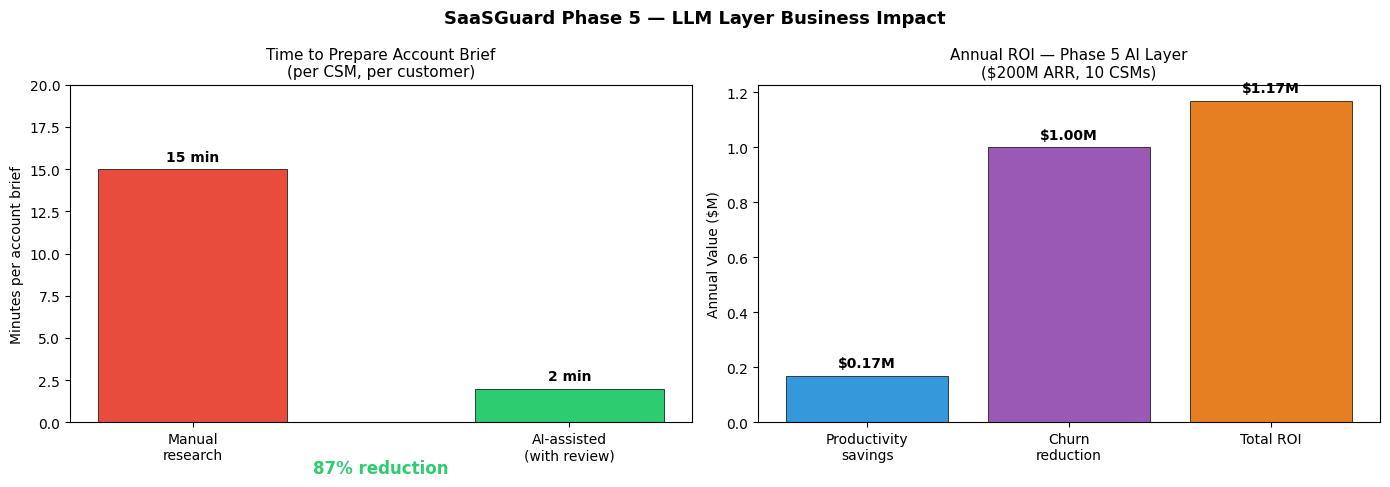

Saved: data/phase5_roi.png


In [9]:
# ── ROI waterfall chart ───────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: time saved breakdown
ax1 = axes[0]
labels = ['Manual\nresearch', 'AI-assisted\n(with review)']
times = [manual_minutes_per_brief, ai_assisted_minutes_per_brief]
colors = ['#e74c3c', '#2ecc71']
bars = ax1.bar(labels, times, color=colors, width=0.5, edgecolor='black', linewidth=0.5)
ax1.set_ylabel('Minutes per account brief')
ax1.set_title('Time to Prepare Account Brief\n(per CSM, per customer)', fontsize=11)
for bar, t in zip(bars, times):
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3, f'{t} min',
             ha='center', va='bottom', fontweight='bold')
ax1.set_ylim(0, 20)
ax1.text(0.5, -0.15, f'{((manual_minutes_per_brief - ai_assisted_minutes_per_brief) / manual_minutes_per_brief):.0%} reduction',
         transform=ax1.transAxes, ha='center', fontsize=12, color='#2ecc71', fontweight='bold')

# Right: annual ROI breakdown
ax2 = axes[1]
roi_labels = ['Productivity\nsavings', 'Churn\nreduction', 'Total ROI']
roi_values = [annual_team_savings, churn_reduction_value, annual_team_savings + churn_reduction_value]
roi_colors = ['#3498db', '#9b59b6', '#e67e22']
ax2.bar(roi_labels, [v/1e6 for v in roi_values], color=roi_colors, edgecolor='black', linewidth=0.5)
ax2.set_ylabel('Annual Value ($M)')
ax2.set_title('Annual ROI — Phase 5 AI Layer\n($200M ARR, 10 CSMs)', fontsize=11)
for i, (label, val) in enumerate(zip(roi_labels, roi_values)):
    ax2.text(i, val/1e6 + 0.02, f'${val/1e6:.2f}M', ha='center', va='bottom', fontweight='bold')

fig.suptitle('SaaSGuard Phase 5 — LLM Layer Business Impact', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('../data/phase5_roi.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: data/phase5_roi.png')